# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test1 solar coordinates

Notebook equivalent of `tests/3_solar/test1_solar_coordinates.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `solar` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `solar` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test1_solar_coordinates"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "3_solar" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\3_solar\test1_solar_coordinates.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `solar` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\solar\test1_solar_coordinates


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_radius_fraction_distance_roundtrip`

**What is checked:** Radius fraction distance roundtrip behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: m/km solar radius conversion must be consistent; Roundtrip through meters must recover rho; Roundtrip through kilometers must recover rho.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_radius_fraction_distance_roundtrip)


Running test_radius_fraction_distance_roundtrip ...

solar radius conversion roundtrip:
rho       : tensor([0.0000, 0.0500, 0.2500, 0.7000, 1.0000], dtype=torch.float64)
radius [m]: tensor([0.0000e+00, 3.4785e+07, 1.7392e+08, 4.8699e+08, 6.9570e+08],
       dtype=torch.float64)
radius [km]: tensor([     0.0000,  34785.0000, 173925.0000, 486990.0000, 695700.0000],
       dtype=torch.float64)
rho from m : tensor([0.0000, 0.0500, 0.2500, 0.7000, 1.0000], dtype=torch.float64)
rho from km: tensor([0.0000, 0.0500, 0.2500, 0.7000, 1.0000], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_radius_fraction_distance_roundtrip


## Test: `test_production_to_surface_path_length`

**What is checked:** Production to surface path length behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Path length in meters must match (1-rho0) R_SUN; Path length m/km conversion must be consistent; Central production path must be one solar radius; Surface production path must be zero.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_production_to_surface_path_length)


Running test_production_to_surface_path_length ...

Radial path length from production point to solar surface:
rho0      : tensor([0.0000, 0.1000, 0.5000, 0.9500, 1.0000], dtype=torch.float64)
length [m]: tensor([6.9570e+08, 6.2613e+08, 3.4785e+08, 3.4785e+07, 0.0000e+00],
       dtype=torch.float64)
length [km]: tensor([695700.0000, 626130.0000, 347850.0000,  34785.0000,      0.0000],
       dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_production_to_surface_path_length


## Test: `test_path_grid_from_profile_radius`

**What is checked:** Path grid from profile radius behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Path grid must start at rho0; Path grid must end at the solar surface; Shell widths must be non-negative; Shell widths must sum to the production-to-surface path.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_path_grid_from_profile_radius)


Running test_path_grid_from_profile_radius ...

solar path grid built from the solar model radius samples:
rho0              : 0.080000
number of points  : 842
first grid point  : 0.080000
last grid point   : 1.000000
min shell width km: 3.478500e+02
max shell width km: 3.478500e+05
total path km     : 640044.000000
expected path km  : 640044.000000
------------------------------------------------------------------------------------------
PASSED: test_path_grid_from_profile_radius


## Plot: `plot_coordinate_conversions()`

**What is checked:** Coordinate conversions behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (coherent_solar_coordinate_conversion.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_coordinate_conversions()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `coherent_solar_coordinate_conversion.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_coordinate_conversions() ...
Saved plot: V:\output\test\solar\test1_solar_coordinates\plot_coordinate_conversions_figure_001.png


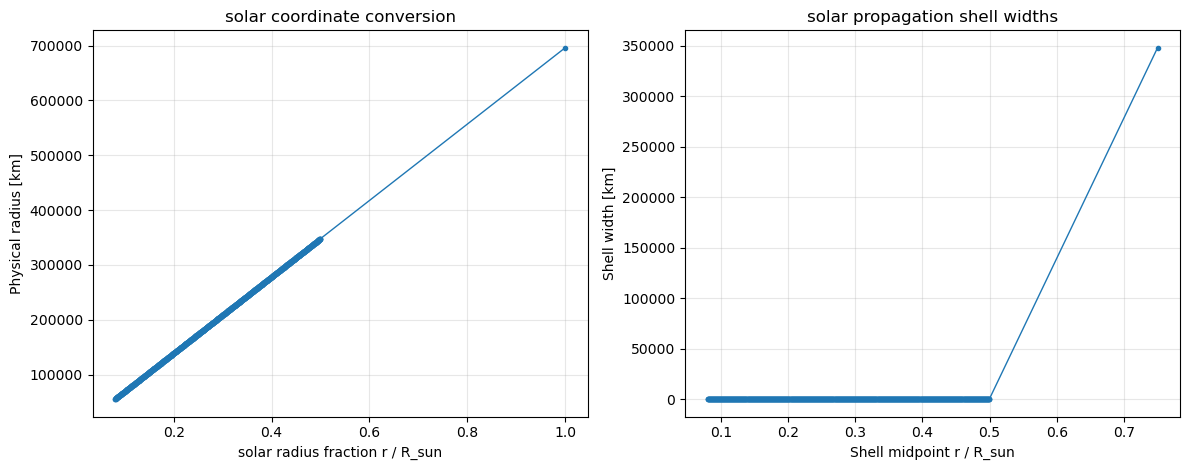

PASSED: plot_coordinate_conversions()


In [7]:
run_notebook_call('plot_coordinate_conversions()', lambda: TEST_MODULE.plot_coordinate_conversions())
